         x1        x2  etiqueta
0 -0.008864  0.113353         0
1  0.242456 -0.075897         0
2 -0.014196 -0.070382         0
3 -0.165579 -0.143002         0
4  0.202125  0.327485         0


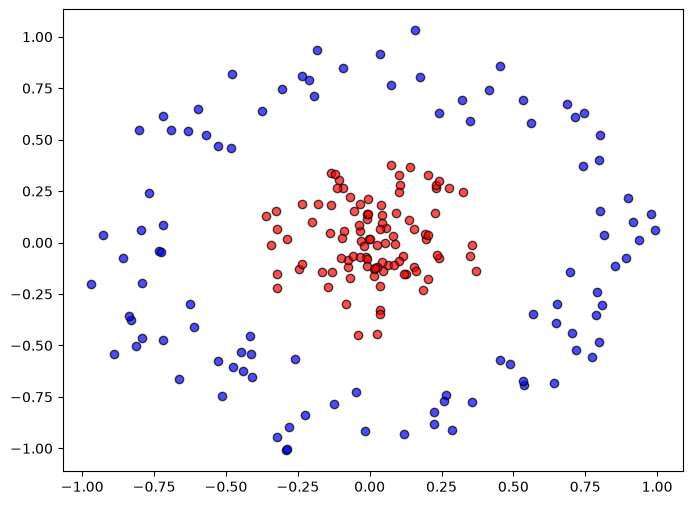

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
# 1. Configurar semilla para reproducibilidad
np.random.seed(42)
 
# 2. Definir parámetros
n_samples_per_class = 100  # 100 para malignas (0) y 100 para benignas (1)
n_total = n_samples_per_class * 2
 
# 3. Generar círculos concéntricos
# Clase 0: Círculo interno (Malignas)
theta_0 = np.random.uniform(0, 2 * np.pi, n_samples_per_class)
r_0 = np.random.uniform(0, 0.4, n_samples_per_class)  # Radio interno pequeño
x1_0 = r_0 * np.cos(theta_0)
x2_0 = r_0 * np.sin(theta_0)
y_0 = np.zeros(n_samples_per_class)
 
# Clase 1: Círculo externo (Benignas)
theta_1 = np.random.uniform(0, 2 * np.pi, n_samples_per_class)
r_1 = np.random.uniform(0.7, 1.0, n_samples_per_class)  # Radio externo grande
x1_1 = r_1 * np.cos(theta_1)
x2_1 = r_1 * np.sin(theta_1)
y_1 = np.ones(n_samples_per_class)
 
# 4. Combinar los datos
x1 = np.concatenate([x1_0, x1_1])
x2 = np.concatenate([x2_0, x2_1])
etiqueta = np.concatenate([y_0, y_1])
 
# 5. Agregar ruido al valor de x2
ruido = np.random.normal(0, 0.08, n_total)  # Ruido gaussiano con media 0 y desviación estándar 0.08
x2 = x2 + ruido
 
# 6. Crear un DataFrame de Pandas
df_celulas = pd.DataFrame({
    'x1': x1,
    'x2': x2,
    'etiqueta': etiqueta.astype(int)
})
 
# Mostrar las primeras 5 filas del dataset
print(df_celulas.head())
 
# 7. (Opcional) Visualizar los datos generados
plt.figure(figsize=(8, 6))
plt.scatter(df_celulas[df_celulas['etiqueta'] == 0]['x1'], 
            df_celulas[df_celulas['etiqueta'] == 0]['x2'], 
            color='red', label='Maligna (0)', alpha=0.7, edgecolors='k')
plt.scatter(df_celulas[df_celulas['etiqueta'] == 1]['x1'], 
            df_celulas[df_celulas['etiqueta'] == 1]['x2'], 
            color='blue', label='Benigna (1)', alpha=0.7, edgecolors='k')

In [17]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Variables predictoras y etiqueta
X = df_celulas[['x1', 'x2']]
y = df_celulas['etiqueta']

# Crear y entrenar la red neuronal MLP
modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8, 4),
    learning_rate_init=0.03,
    max_iter=100,
    tol=0.001,
    early_stopping=False,
    n_iter_no_change=10,
    verbose=True,
    activation='relu',
    random_state=42
)


In [22]:
# Entrenar el modelo
modelo_mlp.fit(X, y)

Iteration 1, loss = 0.79760027
Iteration 2, loss = 0.74333155
Iteration 3, loss = 0.71734086
Iteration 4, loss = 0.69805752
Iteration 5, loss = 0.68430970
Iteration 6, loss = 0.67775199
Iteration 7, loss = 0.67300852
Iteration 8, loss = 0.66652348
Iteration 9, loss = 0.65689550
Iteration 10, loss = 0.64389718
Iteration 11, loss = 0.63115020
Iteration 12, loss = 0.62104250
Iteration 13, loss = 0.61208199
Iteration 14, loss = 0.60322957
Iteration 15, loss = 0.59471857
Iteration 16, loss = 0.58567119
Iteration 17, loss = 0.57590131
Iteration 18, loss = 0.56617047
Iteration 19, loss = 0.55733310
Iteration 20, loss = 0.54875470
Iteration 21, loss = 0.53950396
Iteration 22, loss = 0.53152077
Iteration 23, loss = 0.52582980
Iteration 24, loss = 0.52002966
Iteration 25, loss = 0.51261894
Iteration 26, loss = 0.50394569
Iteration 27, loss = 0.49344494
Iteration 28, loss = 0.48277216
Iteration 29, loss = 0.47102803
Iteration 30, loss = 0.45721018
Iteration 31, loss = 0.44098607
Iteration 32, los

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(16, ...)"
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.03
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"tol tol: float, default=1e-4Tolerance for the optimization. When the loss or score is not improvingby at least ``tol`` for ``n_iter_no_change`` consecutive iterations,unless ``learning_rate`` is set to 'adaptive', convergence isconsidered to be reached and training stops.",0.001
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'


In [23]:
# Darle persistencia al modelo entrenado
import joblib


joblib.dump(modelo_mlp, 'modelo_mlp_circulos_concentricos.pkl')


['modelo_mlp_circulos_concentricos.pkl']

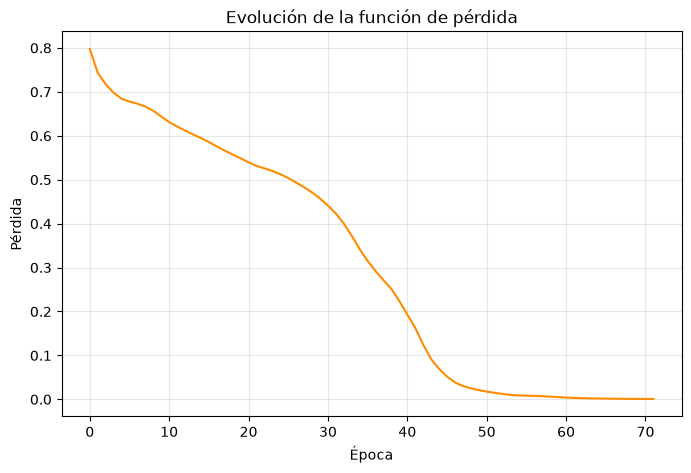

Exactitud en prueba: 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [20]:

# Graficar la evolución de la función de pérdida
plt.figure(figsize=(8, 5))
plt.plot(modelo_mlp.loss_curve_, color='darkorange')
plt.title('Evolución de la función de pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(alpha=0.3)
plt.show()

# Evaluar el modelo
predicciones = modelo_mlp.predict(X)
print(f'Exactitud en prueba: {accuracy_score(y, predicciones):.3f}')
print(classification_report(y, predicciones))

In [26]:
# Predicción para una nueva célula
nueva_celula = pd.DataFrame({'x1': [0.55], 'x2': [0.0]})
clase_predicha = int(modelo_mlp.predict(nueva_celula)[0])
probabilidades = modelo_mlp.predict_proba(nueva_celula)[0]

nombre_clase = 'benigna' if clase_predicha == 1 else 'maligna'
print(f'Predicción para x1=0.55 y x2=0.0: {clase_predicha} ({nombre_clase})')
print(f'Probabilidad de célula maligna (clase 0): {probabilidades[0]:.2%}')
print(f'Probabilidad de célula benigna (clase 1): {probabilidades[1]:.2%}')
print(f'Probabilidad de la clase predicha: {probabilidades[clase_predicha]:.2%}')

Predicción para x1=0.55 y x2=0.0: 1 (benigna)
Probabilidad de célula maligna (clase 0): 14.48%
Probabilidad de célula benigna (clase 1): 85.52%
Probabilidad de la clase predicha: 85.52%
